# Ayudantía 1. Modelos de regresión



## Ejercicio de Regresión Lineal Múltiple

Para este ejercicio trabajaremos con el dataset Medical Cost Personal (insurance) extraído del libro: Machine Learning with R de Brett Lantz (https://github.com/stedy/Machine-Learning-with-R-datasets). El objetivo será a estimar el gasto anual de atención/seguro médico por persona a partir de rasgos demográficos y de estilo de vida de las personas.

El dataset consta de 1338 observaciones y de 7 variables: 

* `age` — Edad de la persona.
* `bmi` — Índice de masa corporal.
* `children` — Número de dependientes declarados.
* `sex` — Sexo registrado.
* `smoker` — Condición de fumador.
* `region` — Zona geográfica.
* `charges` — Gasto anual en atención/seguro médico (variable objetivo).

# Librerías

Dos de las librerías de modelos de regresión lineal más utilizadas en Python son: scikit-learn y statsmodels. Aunque ambas están muy optimizadas, Scikit-learn está orientada principalmente a la predicción, por lo que no dispone de funcionalidades que muestren muchas características del modelo que se deben analizar para hacer inferencia. Statsmodels es mucho más completo en este sentido.

In [37]:
# Tratamiento de datos
import pandas as pd
import numpy as np
import os
import math
import itertools

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesado y modelado estadístico
from scipy import stats
from scipy.stats import pearsonr, normaltest
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Preprocesado y modelado
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (root_mean_squared_error, mean_absolute_error, r2_score)

# Regularización
from sklearn.linear_model import ElasticNetCV

# Configuración de estilos para gráficos
sns.set_theme(context="notebook", style="whitegrid")

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# Cargar el dataset

In [2]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Limpieza

Muchas veces conviene hacer aunque sea un chequeo mínimo antes de modelar recordando que:

* Datos duplicados: inflan la muestra y sesgan coeficientes. 
* Datos Faltantes: interrumpen el pipeline.
* Outliers: afectan MCO y las bandas de confianza. Si no quieres eliminarlos puedes transformarlos con log para ganar robustez o puedes aplicar alguna otra transformación (como winsorización) o por último eliminarlos. 

Duplicados exactos: 1
Se eliminaron duplicados. Nuevo shape: (1337, 7)

Faltantes por columna:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Outliers por IQR:
                    low          high  outliers_IQR
age          -9.000000     87.000000           0.0
bmi          13.675000     47.315000           9.0
children     -3.000000      5.000000           0.0
charges  -13120.716175  34524.777625         139.0


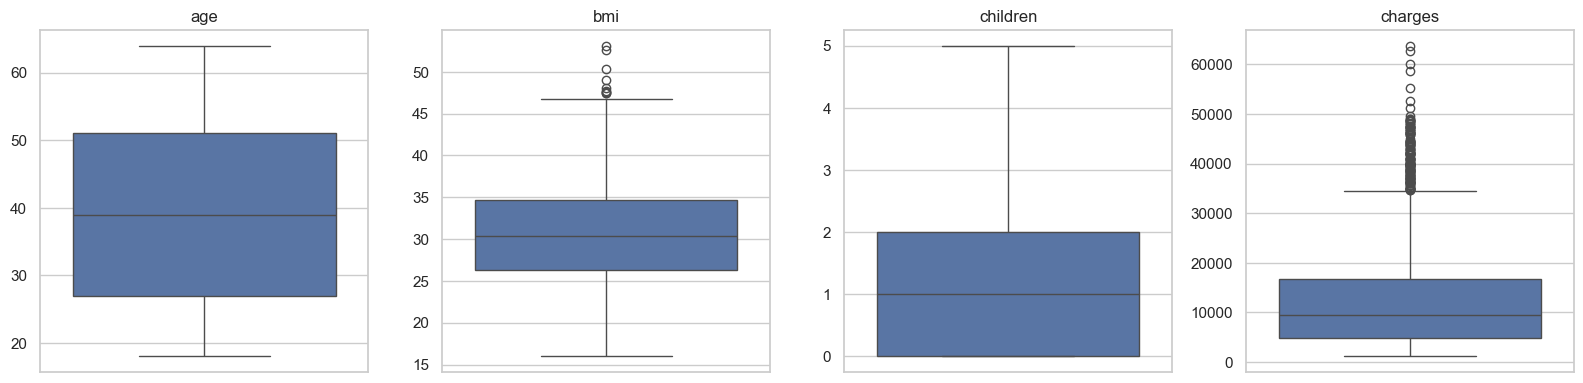

In [3]:
# Duplicados
dup_count = df.duplicated().sum()
print(f"Duplicados exactos: {dup_count}")
if dup_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Se eliminaron duplicados. Nuevo shape:", df.shape)

# Faltantes
na_table = df.isna().sum().sort_values(ascending=False)
print("\nFaltantes por columna:\n", na_table)

# Outliers por el método IQR
num_cols = ["age", "bmi", "children", "charges"]

iqr_info = {}
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low = q1 - 1.5*iqr
    high = q3 + 1.5*iqr
    cnt = ((df[col] < low) | (df[col] > high)).sum()
    iqr_info[col] = {"low": low, "high": high, "outliers_IQR": cnt}
iqr_info = pd.DataFrame(iqr_info).T
print("\nOutliers por IQR:\n", iqr_info)

# Boxplots
fig, axes = plt.subplots(nrows=1, ncols=len(num_cols), figsize=(4*len(num_cols), 4))
if len(num_cols) == 1:
    axes = [axes]  # para iterar de forma uniforme

for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


* Solo había un dato duplicado y ya fué eliminado.
* No habían datos faltantes. En caso de encontrar datos faltantes en un dataset pueden proceder de dos formas: eliminar los faltantes (se sugiere eliminar si la cantidad de datos faltantes no excede un 5% del dataset) o imputar los datos faltantes, según el tipo de dato (MAR, MNAR, MCAR).
* En el caso de los outliers, no los eliminaremos ni transformaremos porque reflejan episodios de gasto alto que son parte del fenómeno a modelar y queremos mantener la comparabilidad con futuras réplicas del flujo. Si el diagnóstico de residuos muestra heterocedasticidad (cuando la varianza de los errores no es constante a lo largo del rango de los valores ajustados), evaluaremos usar log(charges) en la etapa de especificaciones.

# Análisis Exploratorio de las variables (EDA)

## Información sobre las variables

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.2+ KB


Tenemos entonces 4 variables numéricas y 3 variables categóricas.

In [5]:
# Separemos las columnas categóricas y numéricas
cat_cols = ["sex", "smoker", "region"]
num_cols = ["age", "bmi", "children", "charges"]


In [6]:
df[num_cols].describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
print("\Frecuencias por categoría:")
for c in cat_cols:
    print(df[c].value_counts())

\Frecuencias por categoría:
sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


* Vemos que en la variable `charges` la media está muy por encima de la mediana y tiene un máximo muy alto, esto es indicio de que tiene una cola dereca muy marcada.
* La varieble `bmi` muestra dispersión y valores altos.
* La variable ``age`` está en el rango entre 18 y 64.
* La variable ``children`` es baja en promedio y discreta

## Test estadistico de normalidad

En regresión lineal el supuesto de normalidad se exige solo para los residuos del modelo (la diferencia entre valores observados y predichos). Sin embargo, antes de modelar, es útil verificar la forma de la variable objetivo

In [8]:
statistic, p_value = normaltest(df['charges'])
print(f'Test de normalidad para charges:')
print(f'  Statistic: {statistic:.4f}')
print(f'  P-value: {p_value:.4f}')
if p_value < 0.05:
    print('  Result: Data is NOT normally distributed (p < 0.05)')
else:
    print('  Result: Data appears normally distributed (p >= 0.05)')


Test de normalidad para charges:
  Statistic: 336.4416
  P-value: 0.0000
  Result: Data is NOT normally distributed (p < 0.05)


Con este test de normalidad sobre la variable objetivo ``charges`` comprobamos en efecto que la distribución es asimétrica o que tiene cola larga hacia uno de los lados (en este caso hacia la derecha). Esto sugiere aplicar una transformación logarítmica (o raíz cuadrada) a la variable charges para estabilizar la varianza y acercar los residuos a la normalidad.

## Relación entre variables

Estudiamos la relación entre variables para:
- identificar predictores con señal útil,
- detectar colinealidad entre predictores,
- revisar la distribución de cada variable numérica como apoyo al diagnóstico.

,age,bmi,children,charges
age,1.00,0.11,0.04,0.30
bmi,0.11,1.00,0.01,0.20
children,0.04,0.01,1.00,0.07
charges,0.30,0.20,0.07,1.00


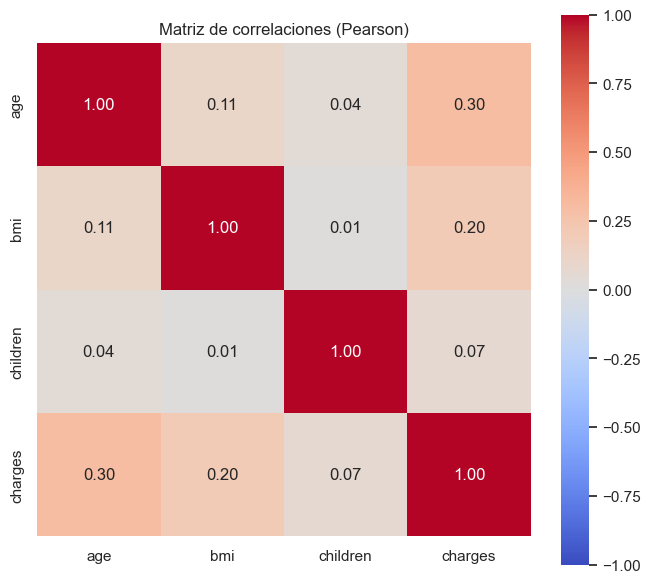

In [9]:
# Correlación entre columnas numéricas
corr = df[num_cols].corr(method="pearson")
display(corr.round(2))

# Heatmap de la matriz de correlaciones
plt.figure(figsize=(1.2*len(num_cols)+2, 1.0*len(num_cols)+2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlaciones (Pearson)")
plt.tight_layout()
plt.show()

Text(0.5, 1.02, 'Scatter plots y distribuciones')

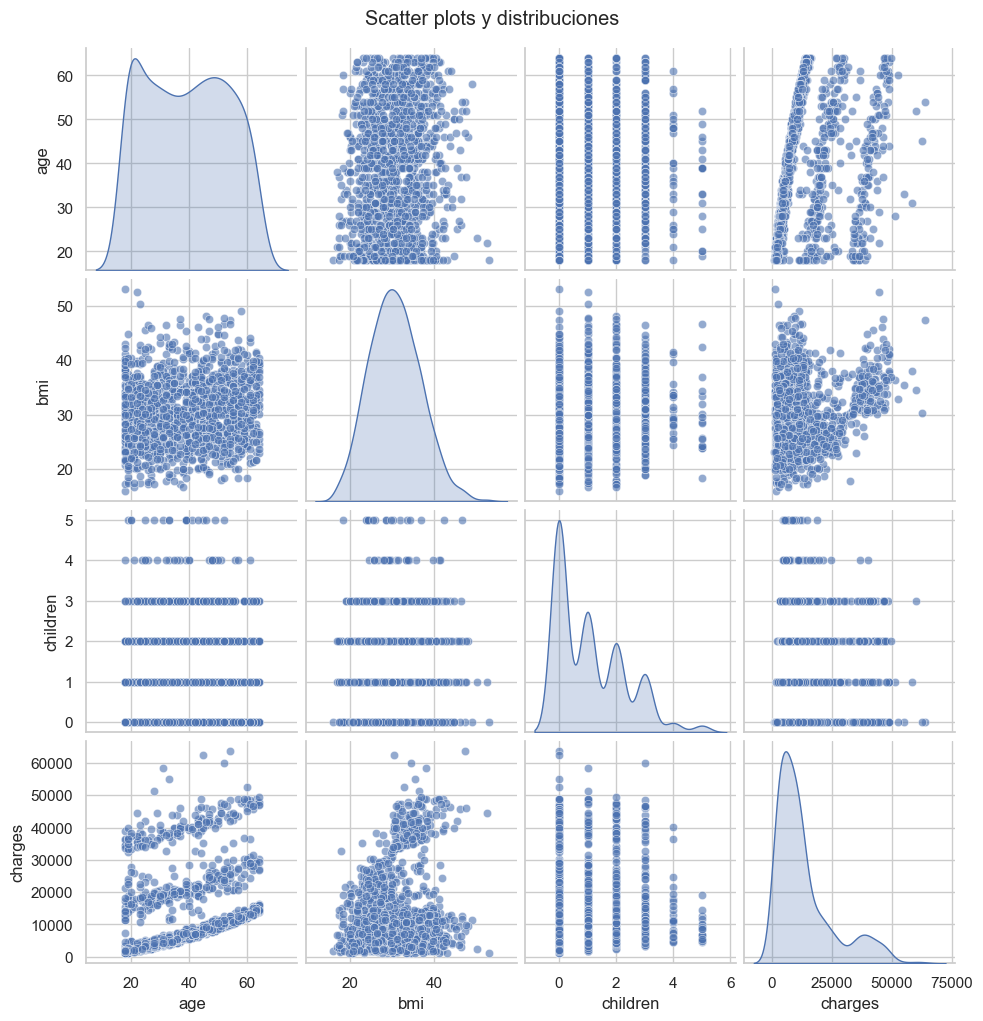

In [10]:
# Scatter plots entre variables numéricas
sns.pairplot(df[num_cols], diag_kind="kde", plot_kws={"alpha":0.6})
plt.suptitle("Scatter plots y distribuciones", y=1.02)  

### Análisis de correlación

* ``age`` presenta una forma bimodal hay concentración tanto en clientes jóvenes como en mayores, lo que sugiere dos segmentos etarios bien definidos.

* ``bmi`` se aproxima a una distribución normal centrada alrededor de 30, lo que indica que la mayoría de los clientes se encuentran dentro de un rango medio de índice de masa corporal.

* ``children`` es discreta,  la mayor parte de los están clientes sin hijos o con uno o dos.

* ``charges`` muestra una fuerte asimetría positiva: la mayoría de los clientes pagan montos bajos o medios, mientras que un pequeño grupo concentra valores muy altos.

* Con respecto a la variable objetivo ``charges`` vemos que ``age`` (con 0.30) y ``bmi`` (con 0.20) tienen una correlación moderada y la variable ``children`` (con 0.07) tiene una correlación prácticamente nula.
    - age y charges tienen una tendencia positiva, los cargos o ingresos aumentan con la edad. Esto sugiere que clientes mayores tienden a generar más ingresos, probablemente por mayor estabilidad económica o por tener más productos contratados.
    - bmi y charges tienen una relación un poco más dispersa, pero se observan algunos grupos con valores de bmi altos y cargos elevados, lo que puede estar asociado a factores indirectos (por ejemplo, seguros de salud más costosos).
    - children y charges no tienen un patrón claro. Tener más hijos no parece estar directamente relacionado con los cargos.

* El análisis sugiere que age y bmi son las variables más prometedoras para explicar charges

* Entre las variables predictoras numéricas tenemos que todos los pares de correlaciones: **age–bmi**, **age–children**, **bmi–children** están cerca de cero. Esto sugiere baja colinealidad. Lo que puede estar indicando que el VIF (Variance Inflation Factor) debería salir controlado. 


## Gráficos

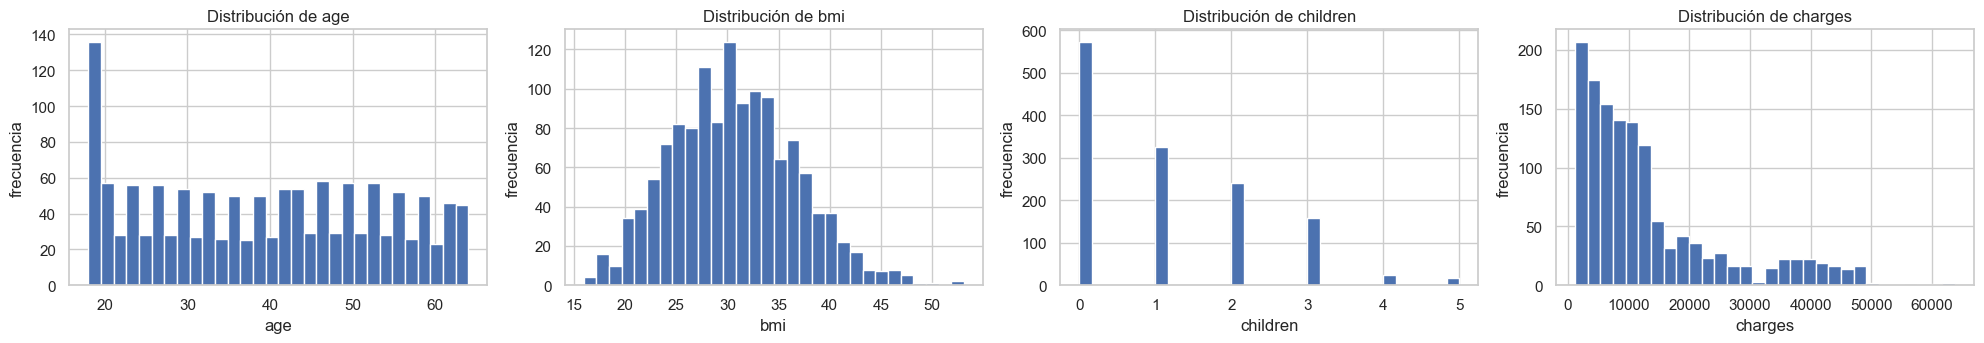

In [11]:
# Gráfico de distribución para las variables numéricas
n = len(num_cols)
if n == 0:
    print("No hay variables numéricas para graficar.")
else:
    # Ajuste automático de grilla
    max_cols = 4  # máximo de columnas en la grilla
    ncols = min(max_cols, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 3.6*nrows))
    # Si n==1, axes no es un array; lo convertimos a lista para iterar cómodo
    if nrows*ncols == 1:
        axes = np.array([axes])

    axes = axes.ravel()  # convertimos a vector para mejorar iteración

    for i, col in enumerate(num_cols):
        ax = axes[i]
        ax.hist(df[col].dropna(), bins=30)
        ax.set_title(f"Distribución de {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("frecuencia")

    # Ocultar ejes sobrantes si la grilla es mayor al número de columnas
    for j in range(i+1, nrows*ncols):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

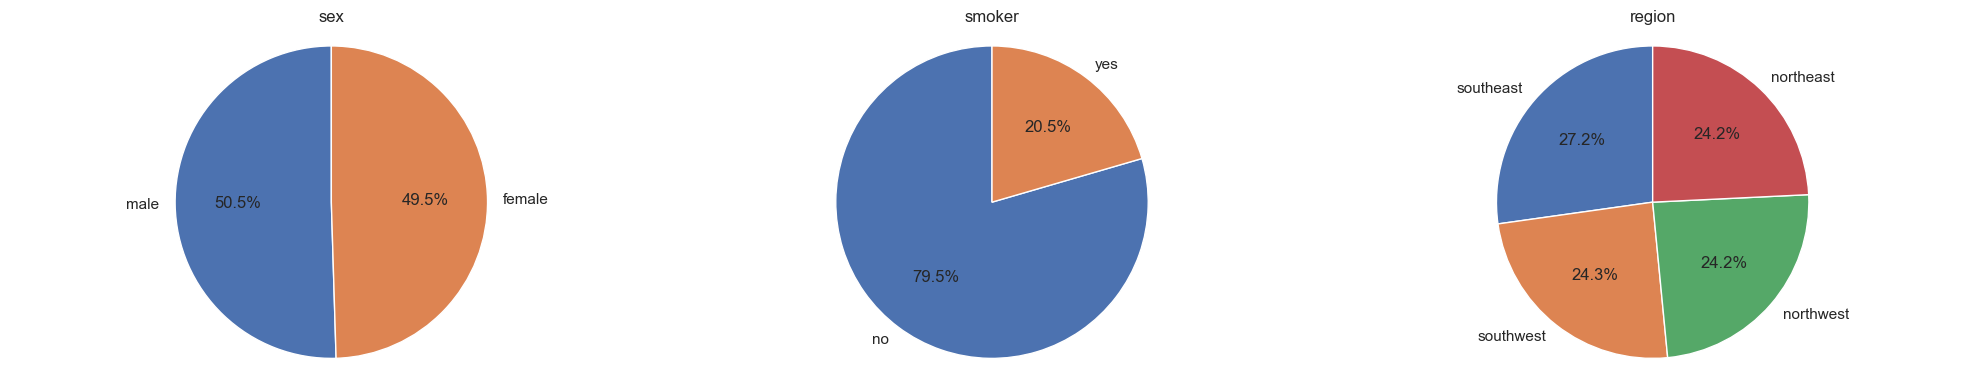

In [12]:
m = len(cat_cols)
fig, axes = plt.subplots(1, m, figsize=(5*n, 4))
if m == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts(dropna=False)
    ax.pie(
        counts.values,
        labels=counts.index.astype(str),
        autopct="%1.1f%%",
        startangle=90
    )
    ax.set_title(f"{col}")
    ax.axis("equal")  # para que sea circular

plt.tight_layout()
plt.show()

### Análisis 

* Como vemos, la variable age es casi uniforme en adultos.

* La variable bmi tiene una distribución con una moderada cola derecha

* La variable children está muy sesgada a 0–2; su efecto será discreto y de magnitud baja.

* La variable charges posee una cola derecha muy marcada. Esto anticipa heterocedasticidad por lo que vale la pena probar log(charges) y comparar diagnóstico de residuos.

# Ajuste del modelo

Se ajusta un modelo lineal múltiple con variable objetivo ``charges``  por persona en función de las variables predictoras ``age``, ``bmi``, ``children``, ``sex``, ``smoker`` y ``region``.

* Vamos a ajustar primero el modelo:
- Modelo1: `charges ~ age + bmi + children + sex + smoker + region`

## División del dataset

Primero vamos a definir los conjuntos de variables predictoras (X) y la variable obyetivo (y).
Luego dividimos los conjuntos de variables en train y test

In [13]:
# Split primero
num_cols2 = ["age", "bmi", "children"]

X = df[num_cols2 + cat_cols].copy()
y = df["charges"].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(1069, 6) (268, 6)
(1069,) (268,)


## Codificación

Vamos a codificar después de hacer la división para evitar que la información del conjunto de prueba influya indebidamente en el conjunto de entrenamiento. Si codificamos (por ejemplo, aplicando one-hot encoding o etiquetas ordinales) antes de separar los datos, cualquier transformación aprenderá de toda la información, incluidas las categorías presentes en el conjunto de prueba, generando una fuga de datos y resultados artificialmente optimistas.

Cuando dividimos primero el dataset (por ejemplo, en entrenamiento y prueba), codificamos únicamente con el conjunto de entrenamiento y luego aplicamos esa misma transformación al conjunto de prueba, garantizando que el modelo solo vea los datos presentes al aprender y mantiene intacta la evaluación. Esto asegura que la evaluación refleje el caso real de datos nuevos sin contaminarse por la estructura global, respetando la distribución y las categorías reales que existen en la práctica.

In [14]:
# One-hot con referencia (drop_first) y luego alineamos columnas
X_train_cod = pd.get_dummies(X_train, columns=cat_cols, drop_first=True, dtype=int)
X_test_cod  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True, dtype=int)

# Asegurar mismas columnas en test que en train
X_test_enc = X_test_cod.reindex(columns=X_train_cod.columns, fill_value=0)

X_train_cod.shape, X_test_cod.shape

((1069, 8), (268, 8))

### Observación

* Usamos One-hot encoding cuando las categorías no tienen un orden natural (por ejemplo, region = [norte, sur, este, oeste])
* Usamos Label Encoding cuando las categorías sí tienen un orden natural o cuando el modelo puede manejar códigos numéricos sin suponer linealidad entre ellos (por ejemplo, risk_level = [low, medium, high]). También en modelos basados en árboles porque esos modelos no interpretan los valores como magnitudes, simplemente dividen por categorías.

In [15]:
X_train_cod.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
1113,23,24.510,0,1,0,0,0,0
967,21,25.745,2,1,0,0,0,0
598,52,37.525,2,0,0,1,0,0
170,63,41.470,0,1,0,0,1,0
275,47,26.600,2,0,0,0,0,0


### Observaciones

* No realizaré escalado ya que las variables numéricas están acotadas age (18–64), bmi (16–53), children (0–5). No hay desbalances extremos de escala entre predictores que compliquen el ajuste. Por lo que mantener age, bmi y children en sus unidades reales nos va a permitir poder interpretar efectos en dólares por año de edad, por punto de BMI o por hijo.

* Recuerden que escalamos cuando el modelo usa distancia o magnitud y cuando las variables numéricas están en rangos muy distintos.

* Para regresión lineal simple o múltiple sin regularización, escalar no es obligatorio si las unidades son comparables. Pero en modelos Ridge, Lasso o Elastic Net, sí conviene escalar porque los coeficientes se penalizan en función de su magnitud; si una variable tiene valores grandes, dominará la penalización injustamente.

## Modelo 1

Modelo1: `charges ~ age + bmi + children + sex + smoker + region`

In [16]:
modelo1 = LinearRegression()
modelo1.fit(X_train_cod, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Métricas

In [17]:
# En train
yhat_train = modelo1.predict(X_train_cod)
yhat_test = modelo1.predict(X_test_cod)

r2_train = r2_score(y_train, yhat_train)
r2_test = r2_score(y_test, yhat_test)

rmse_train = root_mean_squared_error(y_train, yhat_train)
rmse_test  = root_mean_squared_error(y_test, yhat_test)

mae_train  = mean_absolute_error(y_train, yhat_train)
mae_test   = mean_absolute_error(y_test, yhat_test)

print(f"[M1 - train] RMSE train: {rmse_train:,.2f} | MAE train: {mae_train:,.2f} | R² train: {r2_train:.3f}")
print(f"[M1 - test ] RMSE test:  {rmse_test:,.2f}  | MAE test:  {mae_test:,.2f}  | R² test:  {r2_test:.3f}")

[M1 - train] RMSE train: 6,081.11 | MAE train: 4,181.90 | R² train: 0.730
[M1 - test ] RMSE test:  5,956.34  | MAE test:  4,177.05  | R² test:  0.807


Vemos un desempeño similar entre train y test, esto es indicio de que no hay sobreajuste, lo que indica que este modelo mantiene su capacidad predictiva al enfrentarse a datos nuevos, lo que es un signo de buena generalización.

El RMSE está indicando que en promedio las predicciones se desvían alrededor de 6 000 dólares del valor real de los cargos.
y dado que charges puede llegar a 60000 o más, este nivel de error es aceptable.

El MAE indica, en promedio, que el modelo se equivoca unos 4000 dólares por cliente, una medida más robusta frente a valores extremos. Su cercanía al RMSE sugiere que los errores grandes no son excesivos ni frecuentes.

El $R^2$ nos indica que el modelo explica entre 73 % y 81 % de la variabilidad en los cargos médicos de los clientes.

In [18]:
y_pred = modelo1.predict(X_test_enc)

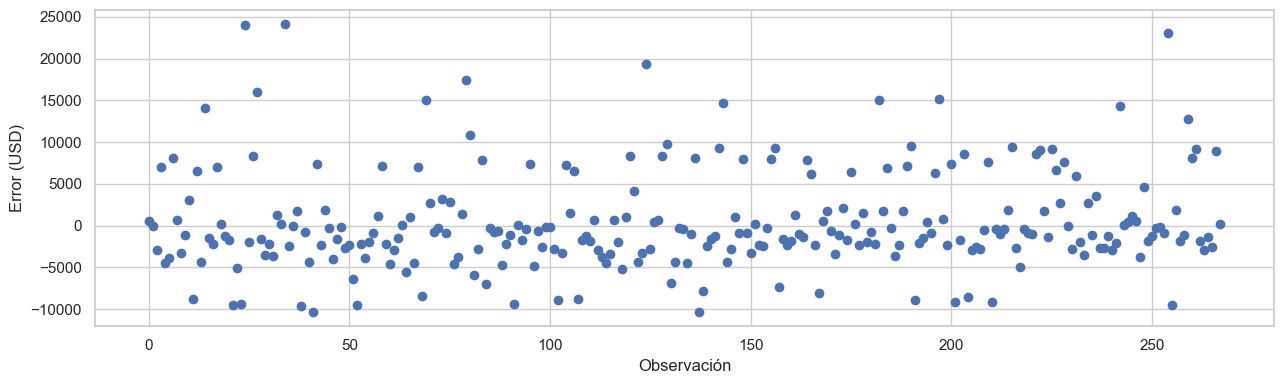

In [19]:
# Residuos vs índice de observación
residuals = y_test.to_numpy() - y_pred
plt.figure(figsize=(13,4))
plt.plot(residuals, 'o')
plt.xlabel('Observación'); plt.ylabel('Error (USD)')
plt.tight_layout()
plt.show()

* Puntos están dispersos alrededor del cero, sin algún tipo de tendencia, lo que sugiere linealidad adecuada entre predictores y la variable objetivo.
* Se observan algunos valores con errores muy altos (mayores a 15 000 USD), posiblemente asociados a fumadores con cargos extremos, que generan asimetría
* No parece haber heterocedasticidad fuerte.
* El modelo no presenta sesgos estructurales, pero algunos individuos generan errores grandes, lo que podría mejorar con transformaciones o modelos regularizados.

## Coeficientes estimados

In [20]:
coeficientes = pd.DataFrame({
    "Variable": X_train_cod.columns,
    "Coeficientes Estimados": modelo1.coef_
})

intercepto = modelo1.intercept_

### Coeficientes Estimados
print("Coeficientes Estimados:")
print(coeficientes)
print(f"\nIntercepto: {intercepto}")

Coeficientes Estimados:
           Variable  Coeficientes Estimados
0               age              248.210720
1               bmi              318.701441
2          children              533.009989
3          sex_male             -101.542054
4        smoker_yes            23077.764593
5  region_northwest             -391.761455
6  region_southeast             -838.919616
7  region_southwest             -659.139752

Intercepto: -11092.652295945962


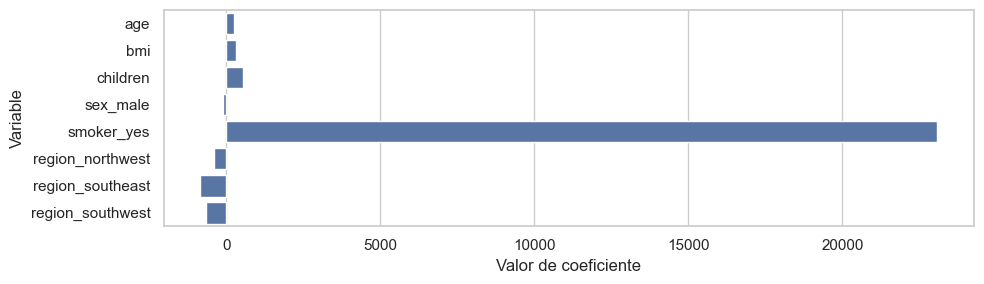

In [21]:
# Grafica de los coeficientes de las variables del modelo ajustado
plt.figure(figsize=(10, 3))
sns.barplot(x=modelo1.coef_.flatten(), y=X_train_cod.columns)
plt.xlabel('Valor de coeficiente'); plt.ylabel('Variable')
plt.tight_layout()
plt.show()

* Sobre los coeficientes:

    * smoker_yes domina claramente el modelo. Su coeficiente es positivo y muy alto ( > 20 000 USD), lo que indica que ser fumador incrementa drásticamente los cargos esperados.
    * children, bmi y age tienen coeficientes positivos pequeños pero consistentes.
    * sex_male tiene un impacto marginal.
    * Las variables sobre región introducen ligeras variaciones, lo que sugiere diferencias regionales pequeñas.
    * Por lo tanto, el hábito de fumar es el principal factor explicativo, y el resto de las variables aportan de forma secundaria.

* El intercepto representa el valor promedio de charges cuando todas las variables son cero o están en su categoría base

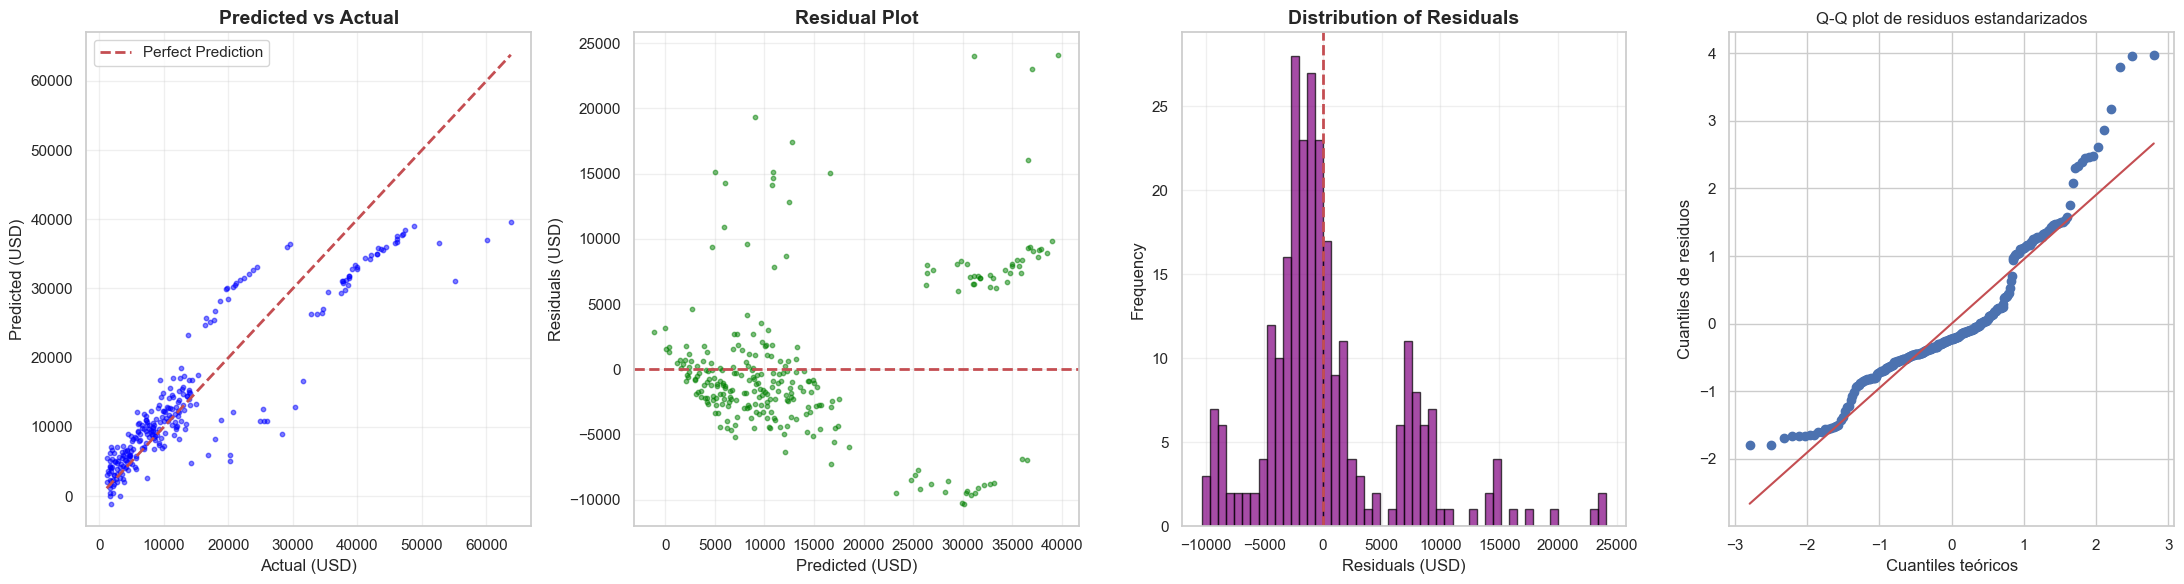

Normaltest residuos: stat=64.797, p-value=8.5e-15
Prediction Analysis:
  Mean Residual: 425.2570
  Std Residual: 5952.2581
  95% Prediction Interval: ± 11666.4258 USD


In [22]:
from scipy import stats

# Predicciones y residuos
y_pred = modelo1.predict(X_test_enc)
residuals = y_test.to_numpy() - y_pred
resid_std = (residuals - residuals.mean()) / residuals.std(ddof=1)

# Figura con 4 paneles
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

# 1) Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.5, s=10, c='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual (USD)', fontsize=12)
axes[0].set_ylabel('Predicted (USD)', fontsize=12)
axes[0].set_title('Predicted vs Actual', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2) Residuals vs Predicted
axes[1].scatter(y_pred, residuals, alpha=0.5, s=10, c='green')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted (USD)', fontsize=12)
axes[1].set_ylabel('Residuals (USD)', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 3) Distribución de residuos
axes[2].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[2].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Residuals (USD)', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].set_title('Distribution of Residuals', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# 4) Q–Q plot de residuos estandarizados
stats.probplot(resid_std, dist="norm", plot=axes[3])
axes[3].set_title("Q-Q plot de residuos estandarizados")
axes[3].set_xlabel("Cuantiles teóricos")
axes[3].set_ylabel("Cuantiles de residuos")

plt.tight_layout()
plt.show()

# Test de normalidad y bandas de predicción
stat, p = stats.normaltest(residuals)
print(f"Normaltest residuos: stat={stat:.3f}, p-value={p:.3g}")

residual_std = residuals.std(ddof=1)
print('Prediction Analysis:')
print(f'  Mean Residual: {residuals.mean():.4f}')
print(f'  Std Residual: {residual_std:.4f}')
print(f'  95% Prediction Interval: ± {1.96 * residual_std:.4f} USD')


### Análisis 

* Predicted vs Actual
    - La mayoría de los puntos se alinean de forma razonable con la línea de referencia.
    - Se observa cierta dispersión creciente a medida que aumentan los cargos reales: los clientes con charges muy altos son más difíciles de predecir, y el modelo tiende a subestimar los valores extremos.
    - Esto confirma que la relación general es buena, aunque el modelo no logra capturar completamente el comportamiento de los valores más grandes (fumadores con cargos muy elevados).

* Residual Plot
    - Los residuos se distribuyen alrededor de cero, sin tendencia clara: no hay evidencia de no linealidad.
    - Se observa una mayor varianza en las predicciones altas, lo que sugiere heterocedasticidad leve (mayor error cuando los cargos son más altos).
    - Este patrón indica que podría ser útil aplicar una transformación logarítmica a charges o introducir regularización para estabilizar la varianza.

* Distribution of Residuals
    - La distribución tiene un pico alrededor de cero, pero muestra asimetría positiva: hay más casos con residuos grandes positivos.
    - Esto coincide con la tendencia a subestimar los casos de alto cargo.
    - Aunque la distribución no es perfectamente normal, no hay colas extremas que invaliden el modelo; simplemente refleja la naturaleza sesgada del gasto médico.

* Q–Q plot de residuos estandarizados
    - Alineación razonable en el centro.
    - Desviaciones sistemáticas en ambas colas y mayor separación en la derecha, consistente con colas pesadas y asimetría positiva.
    - El normaltest confirma no normalidad de los residuos: stat = 64.797, p = 8.5e-15.

* Mean residual = +425.26. como es positivo esto implica una ligera subestimación promedio de las predicciones, del orden de 425 unidades. Es un sesgo pequeño frente a los montos del problema.

* Std residual = 5 941.14. La dispersión típica del error está en torno a 5900. Esto cuadra con los RMSE y con lo visto en los gráficos: variabilidad mayor en casos de gasto alto.

* IC de predicción 95% = ±11 644.64: para una nueva observación individual, el error esperado cae en ese rango con cobertura aproximada del 95%, asumiendo residuos independientes con varianza constante. Es un intervalo amplio, coherente con la cola derecha del fenómeno.

* En conclusión:

El modelo lineal cumple los supuestos básicos, no hay patrones sistemáticos en los residuos, los errores están centrados y con varianza controlada, las desviaciones aparecen principalmente en clientes con cargos muy altos, lo que es esperable en este tipo de datos. 
Por tanto, el modelo está bien calibrado para la mayoría de los casos, pero su precisión podría mejorar con una transformación log(charges) o una técnica regularizada (Ridge, Lasso) que atenúe la influencia de los valores extremos.

### Observación

Existe otra manera de ver un resumen de los parametros y las métricas del modelo a partir del siguiente script.

A partir de estos resultados podemos realizar de forma más directa los cálculos para la selección de variables ya que se necesitan los valores de $R^2$ ajustado, BIC y AIC, de lo contrarrio deben calcularlos de forma manual.

In [23]:
# A la matriz de predictores se le añade una columna de 1s para obtener el intercept del modelo
X_sm = sm.add_constant(X_train_cod, has_constant='add') 
ols_m1 = sm.OLS(y_train, X_sm).fit()

# Resumen
print(ols_m1.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     358.1
Date:                Fri, 07 Nov 2025   Prob (F-statistic):          4.94e-295
Time:                        16:26:07   Log-Likelihood:                -10831.
No. Observations:                1069   AIC:                         2.168e+04
Df Residuals:                    1060   BIC:                         2.172e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.109e+04   1114.260  

### Análisis de resultados

* El modelo explica cerca del 73% de la variabilidad de charges. El pvalor del modelo es altamente significativo (4.94e-295) lo que implica que el conjunto de predictores, en bloque, aporta al modelo.

* smoker_yes ≈ +23 080 USD: efecto dominante, con t ≈ 49 y p < 0.001.

* age ≈ +248 USD/año: efecto positivo y significativo (p < 0.001).

* bmi ≈ +319 USD por punto de BMI: positivo y significativo (p < 0.001).

* children ≈ +533 USD por hijo: efecto pequeño, pero significativo (p = 0.001).

* sex_male y regiones: coeficientes no significativos (p > 0.1).

# Selección de Variables

Los metodos de seleccion de variables implican usar el estimador de mínimos cuadrados para ajustar un modelo lineal con solo un subconjunto de las variables predictoras.

## Método del Coeficiente de determinación ajustado

Calcular todos los coeficientes de determinación ajustados de todos los modelos posibles con la combinación de cualquier número de atributos. Se selecciona el modelo cuyo R2-ajustado sea mayor.

,step,removed,vars,R2_adj
0,keep (8),,8,0.727867
1,drop sex_male (7),sex_male,7,0.728105
2,drop region_northwest (6),region_northwest,6,0.728225
3,drop region_southwest (5),region_southwest,5,0.728234
4,drop region_southeast (4),region_southeast,4,0.728198
5,drop children (3),children,3,0.725442
6,drop bmi (2),bmi,2,0.701202
7,drop age (1),age,1,0.598904


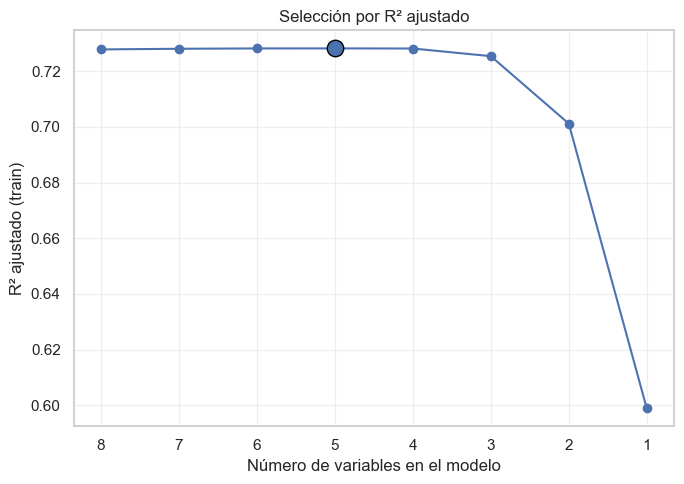


== Modelo final según R² ajustado ==
Variables: ['age', 'bmi', 'children', 'smoker_yes', 'region_southeast']
R2_adj(train) = 0.7282
RMSE(test) = 5,980.94 | MAE(test) = 4,190.78


In [24]:
Xtr = X_train_cod.copy()
Xte = X_test_enc.copy()
ytr = y_train.copy()
yte = y_test.copy()

# Modelo completo
X_sm  = sm.add_constant(Xtr, has_constant='add')
ols_m1 = sm.OLS(ytr, X_sm).fit()

def fit_r2adj(cols):
    X_tr_const = sm.add_constant(Xtr[cols], has_constant='add')
    fit = sm.OLS(ytr, X_tr_const).fit()
    return fit, fit.rsquared_adj

# Ruta completa hasta 1 variable
current_cols = list(Xtr.columns)
hist = [{
    "step": f"keep ({len(current_cols)})",
    "removed": "",
    "vars": len(current_cols),
    "R2_adj": ols_m1.rsquared_adj
}]
while len(current_cols) > 1:
    candidates = []
    for v in current_cols:
        cols_try = [c for c in current_cols if c != v]
        _, r2adj_try = fit_r2adj(cols_try)
        candidates.append((r2adj_try, v, cols_try))
    best_r2adj, removed, best_cols = max(candidates, key=lambda x: x[0])
    current_cols = best_cols
    hist.append({
        "step": f"drop {removed} ({len(current_cols)})",
        "removed": removed,
        "vars": len(current_cols),
        "R2_adj": best_r2adj
    })

tbl_r2adj = pd.DataFrame(hist)
display(tbl_r2adj)

# Índice del mejor paso por R²_aj y reconstrucción del subset ganador
best_idx = tbl_r2adj["R2_adj"].idxmax()

final_vars = list(Xtr.columns)
for _ in range(best_idx):
    candidates = []
    for v in final_vars:
        cols_try = [c for c in final_vars if c != v]
        _, r2adj_try = fit_r2adj(cols_try)
        candidates.append((r2adj_try, v, cols_try))
    best_r2adj, removed, best_cols = max(candidates, key=lambda x: x[0])
    final_vars = best_cols

# Ajuste final y desempeño en test
final_fit_r2adj, _ = fit_r2adj(final_vars)
X_te_const = sm.add_constant(Xte[final_vars], has_constant='add')
yhat_te = final_fit_r2adj.predict(X_te_const)
rmse_te = root_mean_squared_error(yte, yhat_te)
mae_te  = mean_absolute_error(yte, yhat_te)

# Gráfico R²_aj vs número de variables (marcando el mejor paso)
xvals = tbl_r2adj["vars"]
yvals = tbl_r2adj["R2_adj"]

plt.figure(figsize=(7,5))
plt.plot(xvals, yvals, marker='o')
plt.scatter(xvals.iloc[best_idx], yvals.iloc[best_idx], s=140, edgecolor='black', zorder=3)


plt.title("Selección por R² ajustado")
plt.xlabel("Número de variables en el modelo")
plt.ylabel("R² ajustado (train)")
plt.grid(alpha=0.3)
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

# Resultados
print("\n== Modelo final según R² ajustado ==")
print("Variables:", final_vars)
print(f"R2_adj(train) = {final_fit_r2adj.rsquared_adj:.4f}")
print(f"RMSE(test) = {rmse_te:,.2f} | MAE(test) = {mae_te:,.2f}")

## Criterio Cp de Mallows.

* Por lo general, debe buscar modelos donde el valor del Cp de Mallows sea pequeño y esté cercano al número de predictores del modelo más la constante p.

* Un valor del Cp de Mallows pequeño indica que el modelo es relativamente preciso (tiene una varianza pequeña) para estimar los coeficientes de regresión verdaderos y pronosticar futuras respuestas.

* Un valor del Cp de Mallows que esté cerca del número de predictores más la constante indica que, relativamente, el modelo no presenta sesgo en la estimación de los verdaderos coeficientes de regresión y el pronóstico de respuestas futuras. Los modelos con falta de ajuste y sesgo tienen valores de Cp de Mallows más grandes que p.

In [30]:
X_sm_full = sm.add_constant(Xtr, has_constant='add')
model_full = sm.OLS(ytr, X_sm_full).fit()
sse_full = sum(model_full.resid ** 2)
n = len(ytr)
df_full = model_full.df_model + 1  # incluye constante

features = list(Xtr.columns)
cp_values = []
subset_sizes = []
subset_features = []

max_size = min(len(features), 7)  # limita búsqueda

for size in range(1, max_size + 1):
    for subset in itertools.combinations(features, size):
        X_subset = Xtr[list(subset)]
        X_sm_subset = sm.add_constant(X_subset, has_constant='add')
        model_subset = sm.OLS(ytr, X_sm_subset).fit()
        sse_subset = sum(model_subset.resid ** 2)
        p = X_sm_subset.shape[1]
        cp = (sse_subset / (sse_full / (n - df_full))) - (n - 2 * p)
        cp_values.append(cp)
        subset_sizes.append(p)
        subset_features.append(subset)

results_df = pd.DataFrame({
    'subset': subset_features,
    'p': subset_sizes,
    'Cp': cp_values
})

results_df['diff'] = abs(results_df['Cp'] - results_df['p'])
min_diff = results_df['diff'].min()
mejores = results_df[results_df['diff'] == min_diff]
best_index = mejores['p'].idxmin()  

results_df['selected'] = False
results_df.loc[best_index, 'selected'] = True

summary_df = results_df.loc[results_df.groupby('p')['diff'].idxmin()].copy()
summary_df.sort_values('p', inplace=True)
summary_df.reset_index(drop=True, inplace=True)

summary_df


,subset,p,Cp,diff,selected
0,"(smoker_yes,)",2,507.650533,505.650533,False
1,"(age, smoker_yes)",3,107.454006,104.454006,False
2,"(age, bmi, smoker_yes)",4,13.493438,9.493438,False
3,"(age, bmi, children, smoker_yes)",5,3.706890,1.293110,False
4,"(age, bmi, children, sex_male, smoker_yes)",6,5.655636,0.344364,True
5,"(age, bmi, children, sex_male, smoker_yes, reg...",7,7.363286,0.363286,False
6,"(age, bmi, children, sex_male, smoker_yes, reg...",8,7.530250,0.469750,False


## Criteros AIC y BIC

,n_variables,AIC_min,BIC_min
0,1,22087.674182,22097.623140
1,2,21773.922882,21788.846319
2,3,21684.478075,21704.375990
3,4,21674.686998,21699.559392
4,5,21675.541070,21705.387943
5,6,21676.570938,21711.392291
6,7,21678.034236,21717.830067
7,8,21679.960604,21724.730914



== Ganador AIC (global) ==
n_vars = 4, AIC = 21674.7
Variables: ['age', 'bmi', 'children', 'smoker_yes']

== Ganador BIC (global) ==
n_vars = 4, BIC = 21699.6
Variables: ['age', 'bmi', 'children', 'smoker_yes']


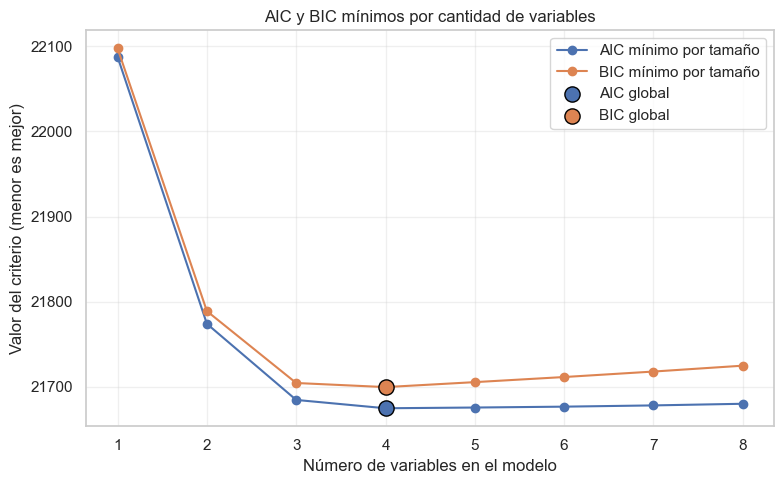

In [26]:
Xtr = X_train_cod.copy()
ytr = y_train.copy()

features = list(Xtr.columns)
nfeat = len(features)

rows = []
for k in range(1, nfeat+1):
    for subset in itertools.combinations(features, k):
        Xk = sm.add_constant(Xtr[list(subset)], has_constant='add')
        fit = sm.OLS(ytr, Xk).fit()
        rows.append({
            "k": k,
            "subset": subset,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "R2_adj": fit.rsquared_adj
        })

res_ic = pd.DataFrame(rows)

# Tabla: para cada cantidad de variables (k), el mínimo AIC y el mínimo BIC alcanzables
tbl_ic = (
    res_ic
    .groupby("k")
    .agg(AIC_min=("AIC","min"), BIC_min=("BIC","min"))
    .reset_index()
    .rename(columns={"k":"n_variables"})
)

# Identifica los ganadores globales por AIC y por BIC
winner_AIC = res_ic.loc[res_ic["AIC"].idxmin()]
winner_BIC = res_ic.loc[res_ic["BIC"].idxmin()]

display(tbl_ic)

print("\n== Ganador AIC (global) ==")
print(f"n_vars = {winner_AIC['k']}, AIC = {winner_AIC['AIC']:.1f}")
print("Variables:", list(winner_AIC["subset"]))

print("\n== Ganador BIC (global) ==")
print(f"n_vars = {winner_BIC['k']}, BIC = {winner_BIC['BIC']:.1f}")
print("Variables:", list(winner_BIC["subset"]))

# Gráfico: AIC y BIC mínimos por tamaño de modelo
plt.figure(figsize=(8,5))
plt.plot(tbl_ic["n_variables"], tbl_ic["AIC_min"], marker="o", label="AIC mínimo por tamaño")
plt.plot(tbl_ic["n_variables"], tbl_ic["BIC_min"], marker="o", label="BIC mínimo por tamaño")

# Marcas de los mínimos globales
plt.scatter([winner_AIC["k"]], [winner_AIC["AIC"]], s=120, edgecolor="black", zorder=3, label="AIC global")
plt.scatter([winner_BIC["k"]], [winner_BIC["BIC"]], s=120, edgecolor="black", zorder=3, label="BIC global")

plt.title("AIC y BIC mínimos por cantidad de variables")
plt.xlabel("Número de variables en el modelo")
plt.ylabel("Valor del criterio (menor es mejor)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Estadístico PRESS

El estadístico PRESS (suma de cuadrados de error de predicción) mide la calidad del modelo de regresión. Se selecciona el modelo que tenga el valor más pequeño del estadístico PRESS.

,n_variables,PRESS_min
0,1,5.897935e+10
1,2,4.400509e+10
2,3,4.045328e+10
3,4,4.007977e+10
4,5,4.012258e+10
5,6,4.015257e+10
6,7,4.020725e+10
7,8,4.027982e+10



== Ganador por PRESS (global) ==
n_vars = 4, PRESS = 40079769794.1
Variables: ['age', 'bmi', 'children', 'smoker_yes']
R2_adj(train) = 0.7282 | AIC = 21674.7 | BIC = 21699.6
RMSE(test) = 5,992.88 | MAE(test) = 4,198.59


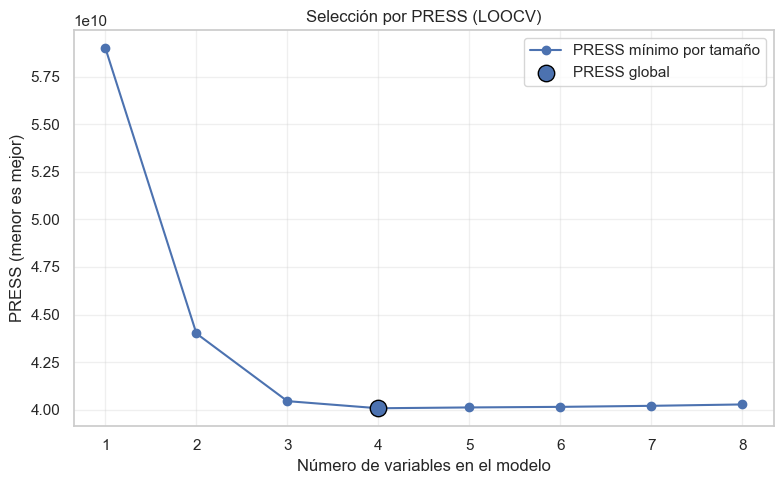

In [34]:
Xtr = X_train_cod.copy()
Xte = X_test_enc.copy()
ytr = y_train.copy()
yte = y_test.copy()
features = list(Xtr.columns)

def press_ols(y, X):
    fit = sm.OLS(y, sm.add_constant(X, has_constant='add')).fit()
    infl = fit.get_influence()
    e    = fit.resid                    # residuos del ajuste
    hii  = infl.hat_matrix_diag         # leverage
    press = np.sum((e / (1.0 - hii))**2)
    return fit, press

rows = []
for k in range(1, len(features)+1):
    for subset in itertools.combinations(features, k):
        cols = list(subset)
        fit, PRESS = press_ols(ytr, Xtr[cols])

        # Evaluación en test para informar del ganador
        yhat_te = fit.predict(sm.add_constant(Xte[cols], has_constant='add'))
        rmse_te = root_mean_squared_error(yte, yhat_te)
        mae_te  = mean_absolute_error(yte, yhat_te)

        rows.append({
            "n_variables": k,
            "subset": tuple(cols),
            "PRESS": PRESS,
            "R2_adj": fit.rsquared_adj,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "RMSE_test": rmse_te,
            "MAE_test": mae_te
        })

res_press = pd.DataFrame(rows)

# Tabla: mínimo PRESS por tamaño de modelo
tbl_press = (
    res_press
    .groupby("n_variables")
    .agg(PRESS_min=("PRESS","min"))
    .reset_index()
)

# Ganador global por PRESS
winner_PRESS = res_press.loc[res_press["PRESS"].idxmin()].copy()
final_cols_press = list(winner_PRESS["subset"])

display(tbl_press)

print("\n== Ganador por PRESS (global) ==")
print(f"n_vars = {winner_PRESS['n_variables']}, PRESS = {winner_PRESS['PRESS']:.1f}")
print("Variables:", final_cols_press)
print(f"R2_adj(train) = {winner_PRESS['R2_adj']:.4f} | AIC = {winner_PRESS['AIC']:.1f} | BIC = {winner_PRESS['BIC']:.1f}")
print(f"RMSE(test) = {winner_PRESS['RMSE_test']:,.2f} | MAE(test) = {winner_PRESS['MAE_test']:,.2f}")

# Gráfico: PRESS mínimo por tamaño
plt.figure(figsize=(8,5))
plt.plot(tbl_press["n_variables"], tbl_press["PRESS_min"], marker="o", label="PRESS mínimo por tamaño")
plt.scatter([winner_PRESS["n_variables"]], [winner_PRESS["PRESS"]], s=140, edgecolor="black", zorder=3, label="PRESS global")
plt.title("Selección por PRESS (LOOCV)")
plt.xlabel("Número de variables en el modelo")
plt.ylabel("PRESS (menor es mejor)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Modelos ganadores por cada método

* Método del Coeficiente de determinación ajustado
    - ``charges`` ~ ``age``+``bmi``+``children``+``smoker_yes``+``region_southeast``

* Criterio Cp de Mallows
    - ``charges`` ~ ``age``+``bmi``+``children``+``sex_male`` +``smoker_yes``

* Criterio AIC
    - ``charges`` ~ ``age``+``bmi``+``children``+``smoker_yes``

* Criterio BIC
    - ``charges`` ~ ``age``+``bmi``+``children``+``smoker_yes``

* Estadístico PRESS
    - ``charges`` ~ ``age``+``bmi``+``children``+``smoker_yes``


* En conclusión, hay consenso fuerte en el modelo de cuatro variables (age, bmi, children, smoker_yes). SI necesitamos agregar análisis por región podemos usar el modelo entregado por el $R^2$ ajustado y si queremos realizar análisis por sexo usamos el modelo entregado por el criterio de Mallows. Para predicción estable y parsimoniosa usamos los demás modelos.

# Técnicas de regularización

Los métodos de regularización ajustan el modelo lineal incluyendo todas las variables y añaden una penalización que contrae los coeficientes hacia cero. Con esto disminuye la varianza de los estimadores y mejora la generalización.

Ridge (L2). Útil cuando hay multicolinealidad entre predictores. Reduce la magnitud de los coeficientes manteniéndolos distintos de cero, estabilizando el modelo cuando la mayoría de las variables aportan señal.

Lasso (L1). Conveniente cuando hay predictores irrelevantes. Induce esparsidad: algunos coeficientes quedan exactamente en cero, lo que actúa como selección automática de variables. Es más estable cuando los predictores no están muy correlacionados entre sí.

Elastic Net (L1+L2). Recomendado cuando coexisten muchas variables, algunas irrelevantes y grupos correlacionados. Combina la selección de Lasso con la estabilidad de Ridge.

Para este ejercicio; dado que el conjunto incluye dummies de región (correlacionadas por construcción) y una señal muy desigual entre predictores ( smoker_yes domina; age y bmi moderados; el resto marginal), elegimos Elastic Net. Esto permite: mantener la estabilidad frente a predictores correlacionados (componente L2), realizar selección efectiva de variables poco útiles (componente L1) y lograr un modelo parsimonioso con desempeño comparable al de Ridge

In [ ]:
# Debemos escalar solo las variables numéricas, por eso las separamos:
num_cols = ["age", "bmi", "children"]
all_cols = list(X_train_cod.columns)
cat_cols_en_dummies = [c for c in all_cols if c not in num_cols]

pre = ColumnTransformer([
    ("scale_num", StandardScaler(), num_cols),
    ("passthrough_cat", "passthrough", cat_cols_en_dummies)
])

cv = KFold(n_splits=10, shuffle=True, random_state=123)

enet = Pipeline([
    ("prep", pre),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],   # mezcla L1/L2 más amplia
        alphas=np.logspace(-4, 2, 200),       # incluye alphas mucho más pequeños
        cv=cv, random_state=123, max_iter=100000
    ))
])

# Entrenar y evaluar
enet.fit(X_train_cod, y_train)
yhat_tr = enet.predict(X_train_cod)
yhat_te = enet.predict(X_test_enc)

rmse_tr = root_mean_squared_error(y_train, yhat_tr)
mae_tr  = mean_absolute_error(y_train, yhat_tr)
rmse_te = root_mean_squared_error(y_test,  yhat_te)
mae_te  = mean_absolute_error(y_test,  yhat_te)

m = enet.named_steps["model"]
print(f"Elastic Net seleccionado: alpha={m.alpha_:.6f} | l1_ratio={m.l1_ratio_}")
print(f"RMSE train: {rmse_tr:,.2f} | MAE train: {mae_tr:,.2f}")
print(f"RMSE test : {rmse_te:,.2f} | MAE test : {mae_te:,.2f}")

# Variables activas
coefs = pd.DataFrame({"Variable": X_train_cod.columns, "Coeficiente": m.coef_})
activos = coefs[coefs["Coeficiente"] != 0].sort_values("Coeficiente", key=np.abs, ascending=False)
print("\nVariables activas (coef ≠ 0):")
print(activos.reset_index(drop=True))

Elastic Net seleccionado: alpha=0.010474 | l1_ratio=0.9
RMSE train: 6,081.41 | MAE train: 4,191.38
RMSE test : 5,973.75 | MAE test : 4,195.90

Variables activas (coef ≠ 0):
           Variable   Coeficiente
0        smoker_yes  22924.452468
1               age   3467.833023
2               bmi   1922.600309
3  region_southeast   -817.391713
4  region_southwest   -651.760092
5          children    637.423765
6  region_northwest   -388.646582
7          sex_male    -90.632789


In [41]:
# Recuperar coeficientes de Elastic Net en unidades originales
from sklearn.utils.validation import check_is_fitted
import numpy as np
import pandas as pd

pipe = enet
check_is_fitted(pipe)

m = pipe.named_steps["model"]
ct = pipe.named_steps["prep"]
scaler = ct.named_transformers_["scale_num"]  # StandardScaler de numéricas
num_cols = ["age", "bmi", "children"]
cat_cols = [c for c in X_train_cod.columns if c not in num_cols]

beta = m.coef_.copy()
intercept = m.intercept_

# separar tramos numéricos y categóricos (en el orden del ColumnTransformer)
b_num = beta[:len(num_cols)]
b_cat = beta[len(num_cols):]

# desescalar: beta_original = beta_estandarizado / scale_
b_num_orig = b_num / scaler.scale_
# ajustar intercepto: a0_orig = a0 - sum(beta_est*mean/scale)
intercept_orig = intercept - np.sum(b_num * scaler.mean_ / scaler.scale_)

coefs_orig = pd.DataFrame({
    "Variable": num_cols + cat_cols,
    "Coeficiente_original": np.r_[b_num_orig, b_cat]
})
print(f"Intercepto (original): {intercept_orig:.4f}")
print(coefs_orig.sort_values("Coeficiente_original", key=np.abs, ascending=False))


Intercepto (original): -11035.9883
           Variable  Coeficiente_original
4        smoker_yes          22924.452468
6  region_southeast           -817.391713
7  region_southwest           -651.760092
2          children            533.782562
5  region_northwest           -388.646582
1               bmi            317.837177
0               age            247.843188
3          sex_male            -90.632789


# Calidad predictiva de los modelos

* Modelo 1, modelo con todas las variables: 
    - `charges ~ age + bmi + children + sex + smoker + region`

* Modelo 2, modelo tomado de la sección de selección de : 
    - ``charges`` ~ ``age``+``bmi``+``children``+``smoker_yes``

* Modelo 3, modelo tomado de la sección de regularización
    - ``charges`` ~ ``age``+``bmi``+``children``+``smoker_yes`` + ``region_southeast``+``region_southwest``+ ``region_northwest``+``sex_male``

In [43]:
# === Columnas ===
num_cols = ["age", "bmi", "children"]
all_cols = list(X_train_cod.columns)

# Modelo 1: full
cols_m1 = all_cols[:]

# Modelo 2: reducido por selección
cols_m2 = ["age", "bmi", "children", "smoker_yes"]

# Modelo 3: regularización con ENet sobre este subconjunto
cols_m3 = ["age", "bmi", "children", "smoker_yes",
           "region_southeast", "region_southwest", "region_northwest", "sex_male"]

def eval_lin(cols):
    Xtr, Xte = X_train_cod[cols], X_test_enc.reindex(columns=cols, fill_value=0)
    ytr, yte = y_train, y_test
    lr = LinearRegression()
    lr.fit(Xtr, ytr)
    yhat_tr = lr.predict(Xtr)
    yhat_te = lr.predict(Xte)
    return {
        "RMSE_train": root_mean_squared_error(ytr, yhat_tr),
        "MAE_train":  mean_absolute_error(ytr, yhat_tr),
        "R2_train":   r2_score(ytr, yhat_tr),
        "RMSE_test":  root_mean_squared_error(yte, yhat_te),
        "MAE_test":   mean_absolute_error(yte, yhat_te),
        "R2_test":    r2_score(yte, yhat_te)
    }

def eval_enet(cols):
    # Escalar solo numéricas y dejar pasar dummies tal cual
    cat_cols = [c for c in cols if c not in num_cols]
    pre = ColumnTransformer([
        ("scale_num", StandardScaler(), [c for c in num_cols if c in cols]),
        ("passthrough_cat", "passthrough", cat_cols)
    ])
    cv = KFold(n_splits=10, shuffle=True, random_state=123)
    enet = Pipeline([
        ("prep", pre),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
            alphas=np.logspace(-4, 2, 200),
            cv=cv, random_state=123, max_iter=100000
        ))
    ])
    Xtr, Xte = X_train_cod[cols], X_test_enc.reindex(columns=cols, fill_value=0)
    ytr, yte = y_train, y_test
    enet.fit(Xtr, ytr)
    yhat_tr = enet.predict(Xtr)
    yhat_te = enet.predict(Xte)
    m = enet.named_steps["model"]
    return {
        "alpha": m.alpha_,
        "l1_ratio": float(m.l1_ratio_),
        "RMSE_train": root_mean_squared_error(ytr, yhat_tr),
        "MAE_train":  mean_absolute_error(ytr, yhat_tr),
        "R2_train":   r2_score(ytr, yhat_tr),
        "RMSE_test":  root_mean_squared_error(yte, yhat_te),
        "MAE_test":   mean_absolute_error(yte, yhat_te),
        "R2_test":    r2_score(yte, yhat_te)
    }

# Evaluaciones
res1 = eval_lin(cols_m1)
res2 = eval_lin(cols_m2)
res3 = eval_enet(cols_m3)

# Tabla comparativa
tabla = pd.DataFrame([
    {"Modelo": "Modelo 1: Full", **res1},
    {"Modelo": "Modelo 2: Selección", **res2},
    {"Modelo": "Modelo 3: Elastic Net", **{k:v for k,v in res3.items() if k not in ["alpha","l1_ratio"]}}
])

# Mostrar hiperparámetros de ENet aparte
alpha_enet  = res3.get("alpha", None)
l1r_enet    = res3.get("l1_ratio", None)

print("== Comparación de calidad predictiva ==")
display(tabla.style.format({
    "RMSE_train": "{:,.2f}", "MAE_train": "{:,.2f}", "R2_train": "{:.3f}",
    "RMSE_test":  "{:,.2f}", "MAE_test":  "{:,.2f}", "R2_test":  "{:.3f}"
}))

if alpha_enet is not None:
    print(f"Elastic Net: alpha={alpha_enet:.6f} | l1_ratio={l1r_enet}")


== Comparación de calidad predictiva ==


,Modelo,RMSE_train,MAE_train,R2_train,RMSE_test,MAE_test,R2_test
0,Modelo 1: Full,"6,081.11","4,181.90",0.730,"5,956.34","4,177.05",0.807
1,Modelo 2: Selección,"6,088.87","4,187.52",0.729,"5,992.88","4,198.59",0.805
2,Modelo 3: Elastic Net,"6,081.41","4,191.38",0.730,"5,973.75","4,195.90",0.806


Elastic Net: alpha=0.010474 | l1_ratio=0.9


Si priorizas interpretabilidad, Modelo 2 es preferible; si prefieres robustez ante sobreajuste, Modelo 3 es una mejor elección.

También pueden probar con interacciones entre variables. La clave es probar interacciones como nuevas variables y decidir con evidencia si valen la pena, por ejemplo pueden probar con las interacciones:
- age*bmi
- age*smoker_yes
- bmi*smoker_yes
- children*smoker_yes
- bmi*sex_male
- smoker_yes*region